<Axes: xlabel='items'>

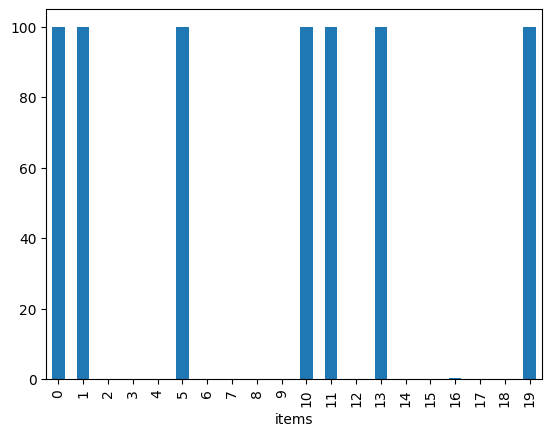

In [2]:
import random
import pandas as pd

items_list = []
total_weight_limit = 200

for _ in range(20):
    items_list.append((random.randrange(0, 100), random.randrange(0, 100)))
# print(items_list)
items = items_list
items = pd.DataFrame(items, columns=['weight', 'value'])
items.index.name = 'items'

items.T


def create_population(population_size: int):
    # We create a list of genomes. Population size is the number of outer loop iterations.
    return [[random.randint(0, 5) == 0 for _ in range(len(items))]
            for _ in range(population_size)]


def fitness(genes: list):
    total_weight = 0
    total_value = 0
    for idx, gene in enumerate(genes):
        if gene:
            total_weight += items['weight'][idx]
            total_value += items['value'][idx]
    if total_weight > total_weight_limit:
        return 0
    else:
        return total_value


def select_winners(population: list):
    population_values = []
    for genes in population:
        value = fitness(genes=genes)
        if value > 0:
            population_values.append((value, genes))
    return [genes for value, genes in
            sorted(population_values, key=lambda x: x[0], reverse=True)]


def select_best(winners: list, population: list, percent=0.2):
    limit = int(percent * len(population))
    if len(winners) > limit:
        best_ones = winners[:limit]
    else:
        best_ones = winners
    return best_ones


def crossover(genes1: list, genes2: list):
    crossover_point = random.randint(1, len(genes1) - 1)
    new_genes = genes1[:crossover_point] + genes2[crossover_point:]
    return new_genes


def mutate(genes: list):
    new_genes = list(genes)
    idx = random.randint(0, len(genes) - 1)
    new_genes[idx] = not bool(genes[idx])
    return new_genes


def random_mutate(genes: list, probability: int = 100):
    if random.randint(0, probability) == 0:
        return mutate(genes)
    else:
        return list(genes)


def next_generation(population: list):
    new_population = []
    all_winners = select_winners(population)

    if len(all_winners) > 0:
        best_ones = select_best(all_winners, population, 0.2)
        for _ in range(len(population)):
            new_genes = crossover(random.choice(best_ones), random.choice(best_ones))
            new_population.append(random_mutate(new_genes))
    else:
        new_population = create_population(len(population))

    return new_population


population = create_population(1000)
for i in range(20):
    new_population = next_generation(population)
    population = new_population

results = pd.concat([pd.DataFrame(population).mean() * 100, items], axis=1)
results.columns = ['selection_rate'] + list(items.columns)
results.index.name = items.index.name
results.T

results['selection_rate'].plot.bar()